# Profile of recovered reads

This notebook profile the recovered reads after spliting, trimming, mapping and filtering.

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind_from_stats, ttest_ind

info = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv")
runs = [
    "20220719_K562_1", 
    "20220719_K562_2", 
    "20220719_K562_3", 
    "20220719_K562_4", 
    "20220729_K562_1", 
    "20220729_K562_2",
]

In [3]:
rows = []
for run in runs:
    tmp = info[info["Run"] == run]
    
    path = "../../../1_NanoNASCseq/results/2_demux/3_splitted/%s/stats.tsv" % run
    d = pd.read_csv(path, sep="\t", index_col=0)
    total = d["Total"].values[0]
    assigned = d["Assigned"].values[0]

    trimmed = 0
    for cell in tmp["Cell"]:
        path = "../../../1_NanoNASCseq/results/2_demux/4_trimmed/%s/%s.log" % (run, cell)
        with open(path) as f:
            for line in f:
                if line.startswith("Pass"):
                    trimmed += int(line.split()[1])

    mapped = 0
    for cell in tmp["Cell"]:
        path = "../../../1_NanoNASCseq/results/3_mapping/1_minimap2/%s/%s.flagstat" % (run, cell)
        with open(path) as f:
            for line in f:
                if "primary mapped" in line:
                    mapped += int(line.split()[0])

    filtered = 0
    for cell in tmp["Cell"]:
        path = "../../../1_NanoNASCseq/results/3_mapping/4_stat_clip/%s/%s.log" % (run, cell)
        filtered += int(open(path).readlines()[-1].split()[0])

    row = [run, total, assigned, trimmed, mapped, filtered]
    rows.append(row)

dat = pd.DataFrame(rows)
dat.columns = ["Run", "TotalReads", "AssignedReads", "TrimmedReads", "MappedReads", "FilteredReads"]
for c in dat.columns[1:]:
    dat["%s.Perc" % c] = dat[c] * 100 / dat["TotalReads"]
dat.to_csv("results/summary_of_recovered_reads.csv", index=False)

In [6]:
dat = pd.read_csv("results/summary_of_recovered_reads.csv")
d = dat[dat.columns[-5:]]
m = pd.DataFrame({"Mean": d.mean(axis=0), "Std": d.std(axis=0, ddof=0), "Size": len(d)})
m.index = ["FlowCell", "Assigned", "Trimmed", "Mapped", "Filtered"]

# ScNaUMI-seq: N = 8
# scCOLOR-seq: N = 6
# sci-fate: 二代的方法
# SCAN-seq: 下载到的是拆分好的数据，无法计算产率
# SCAN-seq2: N = 4

m2 = pd.DataFrame(
    [
        [29.4576, 4.598, 8], 
        [7.345930, 2.644300, 6], 
        [42.048725, 8.449762, 4]
    ],
    index=pd.Index(["ScNaUmi-seq", "scCOLOR-seq", "SCAN-seq2"]), 
    columns=["Mean", "Std", "Size"])
m = pd.concat([m, m2])
m.to_csv("results/recovered_reads.stats.csv")
m

,Mean,Std,Size
FlowCell,100.000000,0.000000,6
Assigned,68.023865,5.138772,6
Trimmed,47.652135,5.234371,6
Mapped,47.301074,5.216237,6
Filtered,39.294867,4.342847,6
ScNaUmi-seq,29.457600,4.598000,8
scCOLOR-seq,7.345930,2.644300,6
SCAN-seq2,42.048725,8.449762,4


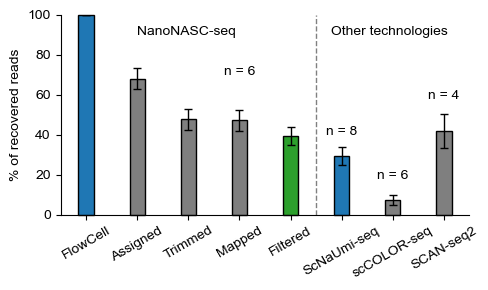

In [8]:
m = pd.read_csv("results/recovered_reads.stats.csv", index_col=0)
xs = np.arange(len(m))
colors = ["C0", "C7", "C7", "C7", "C2"]
ticks = ["FlowCell", "Assigned", "Trimmed", "Mapped", "Filtered", 
         "ScNaUmi-seq", "scCOLOR-seq", "SCAN-seq2"]
plt.figure(figsize=(5, 3))
plt.bar(xs, m["Mean"], yerr=m["Std"], edgecolor="black", width=0.3, lw=1, color=colors, clip_on=False, 
        error_kw={"lw": 1, "capsize": 3})
plt.text(5, 40, "n = 8", ha="center")
plt.text(6, 18, "n = 6", ha="center")
plt.text(7, 58, "n = 4", ha="center")
plt.text(3, 70, "n = %d" % len(d), ha="center")
plt.text(1, 90, "NanoNASC-seq", ha="left")
plt.text(4.8, 90, "Other technologies", ha="left")
plt.axvline(4.5, lw=1, ls="--", color="grey")
plt.ylabel("% of recovered reads")
plt.xticks(np.arange(len(ticks)), ticks, rotation=30)
plt.xlim(-0.5, 7.5)
plt.ylim(0, 100)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/recovered_reads.bar.pdf")
plt.show()
plt.close()

In [30]:
print("NanoNASC-seq vs. ScNaUmi-seq:", ttest_ind_from_stats(
    m.loc["Filtered"]["Mean"], m.loc["Filtered"]["Std"], m.loc["Filtered"]["Number"], 
    m.loc["ScNaUmi-seq"]["Mean"], m.loc["ScNaUmi-seq"]["Std"], m.loc["ScNaUmi-seq"]["Number"]))

print("NanoNASC-seq vs. scCOLOR-seq:", ttest_ind_from_stats(
    m.loc["Filtered"]["Mean"], m.loc["Filtered"]["Std"], m.loc["Filtered"]["Number"], 
    m.loc["scCOLOR-seq"]["Mean"], m.loc["scCOLOR-seq"]["Std"], m.loc["scCOLOR-seq"]["Number"]))

print("NanoNASC-seq vs. ScNaUmi-seq:", ttest_ind_from_stats(
    m.loc["Filtered"]["Mean"], m.loc["Filtered"]["Std"], m.loc["Filtered"]["Number"], 
    m.loc["SCAN-seq2"]["Mean"], m.loc["SCAN-seq2"]["Std"], m.loc["SCAN-seq2"]["Number"]))

NanoNASC-seq vs. ScNaUmi-seq: Ttest_indResult(statistic=4.053698010060066, pvalue=0.0015996830245637423)
NanoNASC-seq vs. scCOLOR-seq: Ttest_indResult(statistic=15.391450153009668, pvalue=2.7288850032833683e-08)
NanoNASC-seq vs. ScNaUmi-seq: Ttest_indResult(statistic=-0.6870156577453449, pvalue=0.5114929803633221)
